In [1]:
%pip install scikit-learn

In [16]:
job_description = """
Looking for a Data Scientist with Python, SQL,
Machine Learning, Pandas, NumPy and AWS skills.
"""

resume_text = """
I have experience in Python, SQL, Pandas,
NumPy and AWS. Built machine learning projects.
"""

In [24]:
import pdfplumber

with pdfplumber.open("../resumes/resume2.pdf") as pdf:
    resume_text = ""

    for page in pdf.pages:
        resume_text += page.extract_text()

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def calculate_match_score(job_desc, resume):

    texts = [job_desc, resume]

    vectorizer = TfidfVectorizer()

    tfidf = vectorizer.fit_transform(texts)

    score = cosine_similarity(
        tfidf[0:1],
        tfidf[1:2]
    )[0][0]

    return round(score * 100, 2)

In [26]:
job_description = """
Data Scientist

Required Skills:
Python
SQL
Pandas
NumPy
Machine Learning
AWS
"""
#create jd

In [27]:
calculate_match_score(
    job_description,
    resume_text
)

np.float64(11.7)

In [28]:
score = calculate_match_score(
    job_description,
    resume_text
)

print(f"Match Score: {score}%")

Match Score: 11.7%


In [29]:
print(resume_text[:1000]) # check if rsume text exists coz percentage is 0.0%

DIYA KASERA
KHANDWA,MP
8319833690 diyakasera254@gmail.com
EDUCATION:
Bachelors of Science (BSC) - DAVV - 2023-2026
College name: Makhanlal Chaturvedi Girls College, Khandwa [MP]
Higher Secondary
Carmel Convent School, Khandwa [MP] - 75% -CBSE (12th)
Sophia Convent School, Khandwa [MP] - 85% -CBSE (10th)
Technical Skills:
 OOPS concept
 Language – C++ , Python, SQL
 Cyber Security
 AWS Cloud Computing –IAM, EC2, ELB ,S3,etc
 Data Science – Seaborn, Matplotlib, Numpy , Pandas ,Probability ,Machine learning ,Git, Git Hub
 VS Code
 Linux
EXPERIENCE:
Teaching – St. Pius School, Khandwa [MP] - 2023
Matchlab Talent – 2024: HR Recruiter intern
The Global Hunt – 2024: HR Recruiter - 2024
Expert Staffing – 2025: HR Recruiter & Consultant
Iconic Business Sol – 2025: HR Recruiter
CERTIFICATIONS:
Certificate of Completion in Data Analytics Job Stimulation- 2025
 Deloitte
Certificate Program in Google Cyber Security – 2025
 GoogleCertificate of completion C, C++ Language – 2024
 Code Care 

In [30]:
 len(resume_text) #Check Length of Resume Text

1330

In [31]:
print(job_description)


Data Scientist

Required Skills:
Python
SQL
Pandas
NumPy
Machine Learning
AWS



In [32]:
skills = ["python", "sql", "pandas", "numpy", "aws"]

for skill in skills:
    if skill in resume_text.lower():
        print(f"Found: {skill}")

Found: python
Found: sql
Found: pandas
Found: numpy
Found: aws


In [33]:
calculate_match_score(
    job_description,
    resume_text
)

np.float64(11.7)

In [34]:
score = calculate_match_score(
    job_description,
    resume_text
)

print(f"Match Score: {score}%")

Match Score: 11.7%


In [35]:
#testing if model behaving properly
job_description = resume_text

In [36]:
score = calculate_match_score(
    job_description,
    resume_text
)

print(score)

100.0


In [37]:
job_description = """
Python
SQL
AWS
Pandas
NumPy
Machine Learning
"""

In [38]:
import pandas as pd

df = pd.read_csv("../jobs.csv")

df.head() 
#now making resume-100 jobs-100 scores

,Title,Company,Location
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA"
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA"
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA"
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP"
4,Product manager,Ramirez Inc,"North Jamieview, AP"


In [39]:
print(df.columns)

Index(['Title', 'Company', 'Location'], dtype='object')


In [41]:
df["Job_Text"] = (
    df["Title"].astype(str) + " " +
    df["Company"].astype(str) + " " +
    df["Location"].astype(str)
)
#create column job text

In [42]:
df[["Job_Text"]].head()

,Job_Text
0,"Senior Python Developer Payne, Roberts and Dav..."
1,Energy engineer Vasquez-Davidson Christophervi...
2,"Legal executive Jackson, Chambers and Levy Por..."
3,Fitness centre manager Savage-Bradley East Sea...
4,"Product manager Ramirez Inc North Jamieview, AP"


In [43]:
scores = []

for job in df["Job_Text"]:
    
    score = calculate_match_score(
        job,
        resume_text
    )
    
    scores.append(score)

In [44]:
df["Match_Score"] = scores

In [45]:
df.head()

,Title,Company,Location,Job_Text,Match_Score
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA","Senior Python Developer Payne, Roberts and Dav...",0.85
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA",Energy engineer Vasquez-Davidson Christophervi...,0.00
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA","Legal executive Jackson, Chambers and Levy Por...",0.00
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP",Fitness centre manager Savage-Bradley East Sea...,0.00
4,Product manager,Ramirez Inc,"North Jamieview, AP","Product manager Ramirez Inc North Jamieview, AP",0.00


In [46]:
ranked_jobs = df.sort_values(
    by="Match_Score",
    ascending=False
)
#highest score first

In [47]:
ranked_jobs[
    ["Title", "Company", "Location", "Match_Score"]
].head(10)
#top 10 jobs

,Title,Company,Location,Match_Score
26,Data scientist,Thomas Group,"Port Robertfurt, AA",2.92
49,"Teacher, primary school","Oliver, Jones and Ramirez","Cindyshire, AA",2.55
15,English as a second language teacher,"Parker, Murphy and Brooks","Mitchellburgh, AE",1.53
5,Medical technical officer,Rogers-Yates,"Davidville, AP",0.97
40,Software Developer (Python),Adams-Brewer,"Brockburgh, AE",0.97
90,Software Developer (Python),Moreno-Rodriguez,"Martinezburgh, AE",0.97
10,Software Engineer (Python),Garcia PLC,"Ericberg, AE",0.97
50,Python Developer,Rivera and Sons,"East Michaelfort, AA",0.90
80,Python Programmer (Entry-Level),Mathews Inc,"Robertborough, AP",0.90
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA",0.85


In [49]:
ranked_jobs.to_csv(
    "job_recommendations.csv",
    index=False
)
print("created")

created


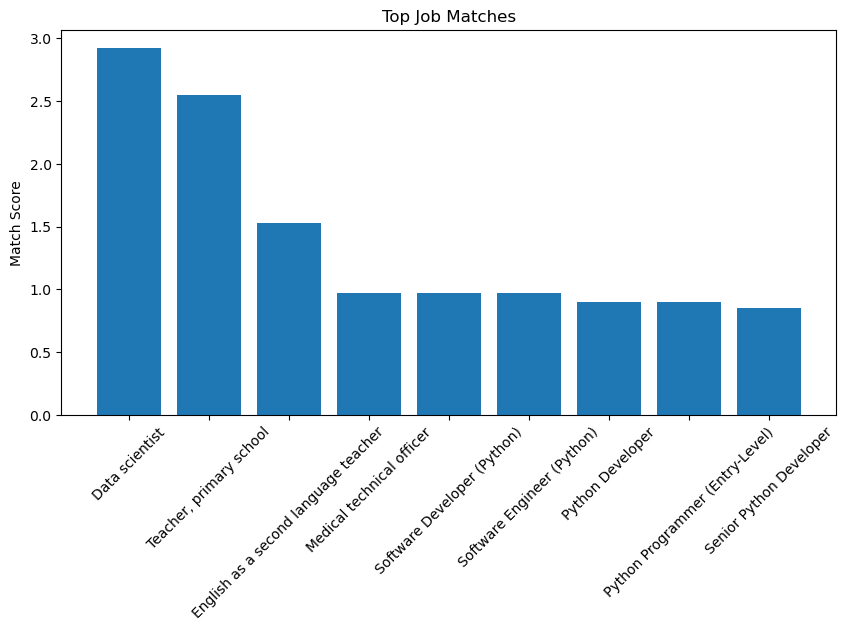

In [50]:
import matplotlib.pyplot as plt

top10 = ranked_jobs.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["Title"],
    top10["Match_Score"]
)

plt.xticks(rotation=45)
plt.title("Top Job Matches")
plt.ylabel("Match Score")

plt.show()
#visualize top match

In [51]:
skills_list = [
    "python",
    "sql",
    "aws",
    "pandas",
    "numpy",
    "tensorflow",
    "machine learning",
    "deep learning",
    "power bi",
    "tableau",
    "excel",
    "statistics",
    "data analysis",
    "data visualization",
    "scikit-learn"
]
#creating skills dictionary

In [52]:
def extract_skills(text):
    
    found_skills = []
    
    text = text.lower()
    
    for skill in skills_list:
        if skill.lower() in text:
            found_skills.append(skill)
    
    return found_skills
#skills extraction function

In [53]:
resume_skills = extract_skills(resume_text)

print(resume_skills)
#extract resume skills

['python', 'sql', 'aws', 'pandas', 'numpy', 'machine learning']


In [54]:
job_text = """
Python
SQL
AWS
Machine Learning
TensorFlow
"""
#jd

In [55]:
job_skills = extract_skills(job_text)

print(job_skills)

['python', 'sql', 'aws', 'tensorflow', 'machine learning']


In [56]:
def skill_match_score(
    resume_skills,
    job_skills
):
    
    matching = set(resume_skills) & set(job_skills)
    
    score = (
        len(matching)
        / len(job_skills)
    ) * 100
    
    return round(score, 2)
#    calculaate skill match

In [57]:
score = skill_match_score(
    resume_skills,
    job_skills
)

print(score)
#testing

80.0


In [58]:
missing_skills = (
    set(job_skills)
    - set(resume_skills)
)

print("Missing Skills:")
print(missing_skills) 
#show missing skills

Missing Skills:
{'tensorflow'}
